In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
Data_PSH_Red = pd.read_csv("./PS-H_Red.csv")
Data_PSH_Yellow = pd.read_csv("./PS-H_Yellow.csv")
Data_PSH_Green = pd.read_csv("./PS-H_Green.csv")

Data_PSL_Red = pd.read_csv("./PS-L_Red.csv")
Data_PSL_Yellow = pd.read_csv("./PS-L_Yellow.csv")
Data_PSL_Green = pd.read_csv("./PS-L_Green.csv")

In [3]:
ColorsByMolecularMass = ["#9e2a2b","#e09f3e","#3a5a40","#9e2a2b","#e09f3e","#3a5a40","#9e2a2b","#e09f3e","#3a5a40","#9e2a2b","#e09f3e","#3a5a40"]

In [4]:
Data_PSH = pd.read_csv("./PS-H_Standard.csv")
Data_PSL = pd.read_csv("./PS-L_Standard.csv")

In [5]:
def ConvertPSH_rv_mp(RvValues):
    x = np.array(Data_PSH.rv)
    y = np.log(np.array(Data_PSH.Mp))
    # plt.scatter(x,y)

    coefficients = np.polyfit(x,y,3)
    p = np.poly1d(coefficients)
    xp = np.linspace(np.min(Data_PSH.rv),np.max(Data_PSH.rv),100)
    # plt.scatter(xp,p(xp))
    
    LoggedMpValues = p(RvValues)
    MpValues = np.exp(LoggedMpValues)
    return MpValues

In [6]:
PSHSomeRvValues = np.linspace(0,28,100)
PSHSomeMpValues = ConvertPSH_rv_mp(PSHSomeRvValues)

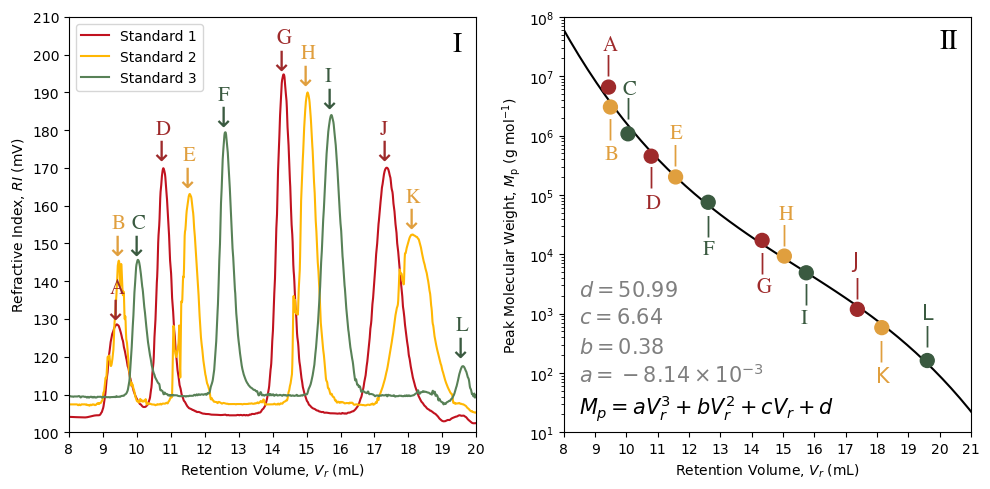

In [7]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10, 5))

ax1.plot(Data_PSH_Red.rv,Data_PSH_Red.ri,color="#c1121f",label="Standard 1")
ax1.plot(Data_PSH_Yellow.rv,Data_PSH_Yellow.ri,color="#ffb703",label="Standard 2")
ax1.plot(Data_PSH_Green.rv,Data_PSH_Green.ri,color="#588157",label="Standard 3")

ax1.text(x=9.43-0.43,y=130,s="↓",color="#9e2a2b",fontsize=20)
ax1.text(x=10.79-0.43,y=172,s="↓",color="#9e2a2b",fontsize=20)
ax1.text(x=14.33-0.43,y=196,s="↓",color="#9e2a2b",fontsize=20)
ax1.text(x=17.37-0.43,y=172,s="↓",color="#9e2a2b",fontsize=20)

ax1.text(x=9.49-0.43,y=147,s="↓",color="#e09f3e",fontsize=20)
ax1.text(x=11.57-0.43,y=165,s="↓",color="#e09f3e",fontsize=20)
ax1.text(x=15.04-0.43,y=192,s="↓",color="#e09f3e",fontsize=20)
ax1.text(x=18.15-0.43,y=154,s="↓",color="#e09f3e",fontsize=20)

ax1.text(x=10.05-0.43,y=147,s="↓",color="#3a5a40",fontsize=20)
ax1.text(x=12.61-0.43,y=181,s="↓",color="#3a5a40",fontsize=20)
ax1.text(x=15.74-0.43,y=186,s="↓",color="#3a5a40",fontsize=20)
ax1.text(x=19.60-0.43,y=120,s="↓",color="#3a5a40",fontsize=20)


ax1.text(x=9.43-0.22,y=130+7,s="A",color="#9e2a2b",fontsize=15,font="times")
ax1.text(x=10.79-0.22,y=172+7,s="D",color="#9e2a2b",fontsize=15,font="times")
ax1.text(x=14.33-0.22,y=196+7,s="G",color="#9e2a2b",fontsize=15,font="times")
ax1.text(x=17.37-0.22,y=172+7,s="J",color="#9e2a2b",fontsize=15,font="times")

ax1.text(x=9.49-0.22,y=147+7,s="B",color="#e09f3e",fontsize=15,font="times")
ax1.text(x=11.57-0.22,y=165+7,s="E",color="#e09f3e",fontsize=15,font="times")
ax1.text(x=15.04-0.22,y=192+7,s="H",color="#e09f3e",fontsize=15,font="times")
ax1.text(x=18.15-0.22,y=154+7,s="K",color="#e09f3e",fontsize=15,font="times")

ax1.text(x=10.05-0.22,y=147+7,s="C",color="#3a5a40",fontsize=15,font="times")
ax1.text(x=12.61-0.22,y=181+7,s="F",color="#3a5a40",fontsize=15,font="times")
ax1.text(x=15.74-0.22,y=186+7,s="I",color="#3a5a40",fontsize=15,font="times")
ax1.text(x=19.60-0.22,y=120+7,s="L",color="#3a5a40",fontsize=15,font="times")

ax1.set_xlim(8,20)
ax1.set_ylim(100,200)
ax1.set_yticks(np.linspace(100,210,12))
ax1.set_xticks(np.linspace(8,20,13))

ax1.set_xlabel(r"Retention Volume, $V_{r}$ (mL)")
ax1.set_ylabel(r"Refractive Index, $RI$ (mV)")


ax2.scatter(Data_PSH.rv,Data_PSH.Mp,c=ColorsByMolecularMass,zorder=1,s=100)
ax2.plot(PSHSomeRvValues,PSHSomeMpValues,zorder=-1,color="black")
ax2.set_ylim(10,100000000)
ax2.set_yscale('log')
ax2.set_xlim(8,21)
ax2.set_xticks(np.linspace(8,21,14))
ax2.set_xlabel(r"Retention Volume, $V_{r}$ (mL)")
ax2.set_ylabel(r"Peak Molecular Weight, $M_{\text{p}}$ (g mol$^{-1}$)")

ax2.text(x=9.43-0.13,y=13000000,s="|",color="#9e2a2b",fontsize=15)
ax2.text(x=9.49-0.13,y=1100000,s="|",color="#e09f3e",fontsize=15)
ax2.text(x=10.05-0.13,y=2400000,s="|",color="#3a5a40",fontsize=15)
ax2.text(x=10.79-0.13,y=170000,s="|",color="#9e2a2b",fontsize=15)
ax2.text(x=11.57-0.13,y=400000,s="|",color="#e09f3e",fontsize=15)
ax2.text(x=12.61-0.13,y=25000,s="|",color="#3a5a40",fontsize=15)
ax2.text(x=14.33-0.13,y=6000,s="|",color="#9e2a2b",fontsize=15)
ax2.text(x=15.04-0.13,y=18000,s="|",color="#e09f3e",fontsize=15)
ax2.text(x=15.74-0.13,y=1800,s="|",color="#3a5a40",fontsize=15)
ax2.text(x=17.37-0.13,y=2300,s="|",color="#9e2a2b",fontsize=15)
ax2.text(x=18.15-0.13,y=200,s="|",color="#e09f3e",fontsize=15)
ax2.text(x=19.60-0.13,y=350,s="|",color="#3a5a40",fontsize=15)


ax2.text(x=9.43-0.18,y=28000000,s="A",color="#9e2a2b",fontsize=15,font="times")
ax2.text(x=9.49-0.18,y=400000,s="B",color="#e09f3e",fontsize=15,font="times")
ax2.text(x=10.05-0.18,y=5000000,s="C",color="#3a5a40",fontsize=15,font="times")
ax2.text(x=10.79-0.18,y=60000,s="D",color="#9e2a2b",fontsize=15,font="times")
ax2.text(x=11.57-0.18,y=900000,s="E",color="#e09f3e",fontsize=15,font="times")
ax2.text(x=12.61-0.18,y=10000,s="F",color="#3a5a40",fontsize=15,font="times")
ax2.text(x=14.33-0.18,y=2300,s="G",color="#9e2a2b",fontsize=15,font="times")
ax2.text(x=15.04-0.18,y=40000,s="H",color="#e09f3e",fontsize=15,font="times")
ax2.text(x=15.74-0.18,y=700,s="I",color="#3a5a40",fontsize=15,font="times")
ax2.text(x=17.37-0.18,y=6000,s="J",color="#9e2a2b",fontsize=15)
ax2.text(x=18.15-0.18,y=70,s="K",color="#e09f3e",fontsize=15)
ax2.text(x=19.60-0.18,y=800,s="L",color="#3a5a40",fontsize=15)

ax2.text(x=8.5,y=20,s=r"$M_{p}=aV_{r}^{3}+bV_{r}^{2}+cV_{r}+d$",color="black",fontsize=15,alpha=1)
ax2.text(x=8.5,y=70,s=r"$a=-8.14 \times 10^{-3}$",color="black",fontsize=15,alpha=0.5)
ax2.text(x=8.5,y=220,s=r"$b=0.38$",color="black",fontsize=15,alpha=0.5)
ax2.text(x=8.5,y=700,s=r"$c=6.64$",color="black",fontsize=15,alpha=0.5)
ax2.text(x=8.5,y=2000,s=r"$d=50.99$",color="black",fontsize=15,alpha=0.5)

ax1.text(x=19.3,y=201,s="I",fontsize=20,font='times')
ax2.text(x=20,y=30000000,s="II",fontsize=20,font='times')

ax1.legend()

fig.tight_layout()
plt.savefig(fname='GPCCalibExplain.png',bbox_inches="tight",dpi=1000,format='png')

In [8]:
def AnXAxisCutter(LowerLimit,UpperLimit,Dataframe):
    StartIdx = 0
    EndIdx = len(Dataframe)-1
    LowerLimitIdx = 0
    UpperLimitIdx = 0
    for count,i in enumerate(Dataframe.rv):
        if i > LowerLimit:
            LowerLimitIdx = count
            break
    for count,i in enumerate(Dataframe.rv):
        if i > UpperLimit:
            UpperLimitIdx = count
            break
    FirstDropRange = np.linspace(StartIdx,LowerLimitIdx,(LowerLimitIdx-StartIdx)+1).astype(int).tolist()
    SecondDropRange = np.linspace(UpperLimitIdx,EndIdx,(EndIdx-UpperLimitIdx)+1).astype(int).tolist()
    NewDataframe = Dataframe.drop(FirstDropRange)
    NewestDataframe = NewDataframe.drop(SecondDropRange)
    return NewestDataframe

In [9]:
def RemoveBaseline(Baseline,RawData):
    ProcessedData = []
    for i in RawData:
        j = i-Baseline
        if j < 0:
            ProcessedDatum = 0
            ProcessedData.append(ProcessedDatum)
        else:
            ProcessedDatum = j
            ProcessedData.append(ProcessedDatum)
    return ProcessedData

In [10]:
Data_HMWR_PPSI = pd.read_csv("./HMWR_PPI.csv")
Data_HMWR_PPSI_CutOff = AnXAxisCutter(7.6,20.2,Data_HMWR_PPSI)

Baseline_HMWR_PPSI = np.array(Data_HMWR_PPSI_CutOff.ri)[-1]
Data_HMWR_PPSI_rv = Data_HMWR_PPSI_CutOff.rv
Data_HMWR_PPSI_ri = RemoveBaseline(Baseline_HMWR_PPSI,Data_HMWR_PPSI_CutOff.ri)
Data_HMWR_PPSI_mp = list(ConvertPSH_rv_mp(np.array(Data_HMWR_PPSI_CutOff.rv).tolist()))

In [11]:
Area_PPSI_ri = np.trapz(y=Data_HMWR_PPSI_ri,x=Data_HMWR_PPSI_rv,axis=-1)
Data_HMWR_PPSI_wf = []
Data_HMWR_PPSI_nwf = []
rv_last = 0
ri_last = 0
mw_last = 0
for count,(rv,ri,mw) in enumerate(zip(Data_HMWR_PPSI_rv,Data_HMWR_PPSI_ri,Data_HMWR_PPSI_mp)):
    rv_chng = abs(rv-rv_last)
    ri_chng = ri-ri_last
    if count == 0:
        rv_last = rv
        ri_last = ri
        mw_last = mw
        continue
    elif ri_chng<=0:
        area_sq = ri*rv_chng
        area_tri = (rv_chng*abs(ri-ri_last))/2
        area = area_sq-area_tri
        weightfraction = area/Area_PPSI_ri
        Data_HMWR_PPSI_wf.append(weightfraction)
        # mw_logchng = np.log(mw_last)-np.log(mw)
        mw_logchng = abs(np.log(mw)-np.log(mw_last))
        differntialDistribVal = weightfraction/mw_logchng
        Data_HMWR_PPSI_nwf.append(differntialDistribVal)
        rv_last = rv
        ri_last = ri
        mw_last = mw
        continue
    else:
        area_sq = ri*rv_chng
        area_tri = (rv_chng*abs(ri-ri_last))/2
        area = area_sq+area_tri
        weightfraction = area/Area_PPSI_ri
        Data_HMWR_PPSI_wf.append(weightfraction)
        # mw_logchng = np.log(mw_last)-np.log(mw)
        mw_logchng = abs(np.log(mw)-np.log(mw_last))
        differntialDistribVal = weightfraction/mw_logchng
        Data_HMWR_PPSI_nwf.append(differntialDistribVal)
        rv_last = rv
        ri_last = ri
        mw_last = mw
        continue

In [12]:
rv_last = 0
ri_last = 0
mp_last = 0
new_rv_lis = []
new_ri_lis = []
new_mp_lis = []
for count,(rv,ri,mp) in enumerate(zip(Data_HMWR_PPSI_rv,Data_HMWR_PPSI_ri,Data_HMWR_PPSI_mp)):
    if count == 0:
        rv_last = rv
        ri_last = ri
        mp_last = mp
        continue
    else:
        new_rv_lis.append((rv+rv_last)/2)
        new_ri_lis.append((ri+ri_last)/2)
        new_mp_lis.append((mp+mp_last)/2)
        rv_last = rv
        ri_last = ri
        mp_last = mp
Data_HMWR_PPSI_rv = new_rv_lis
Data_HMWR_PPSI_ri = new_ri_lis
Data_HMWR_PPSI_mp = new_mp_lis

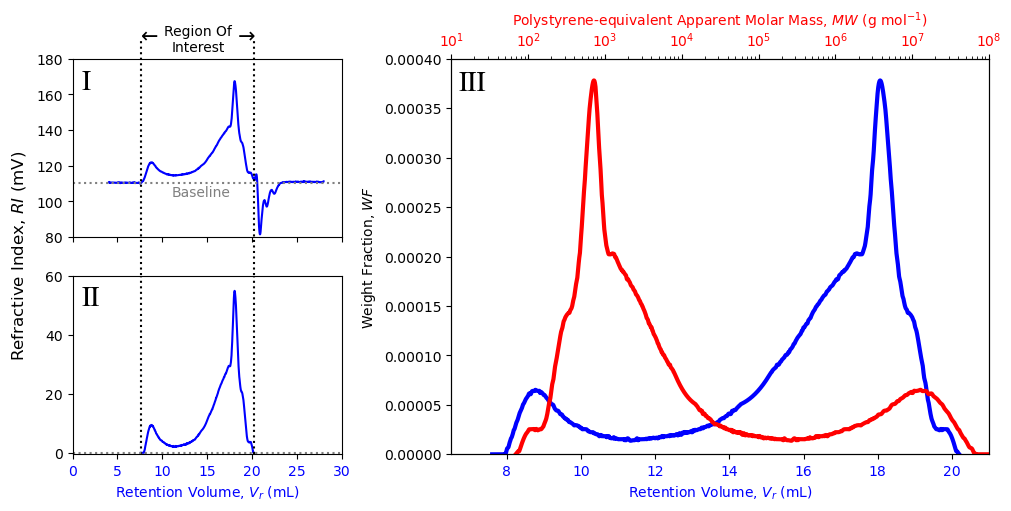

In [13]:
gs_kw = dict(width_ratios=[0.5, 1],height_ratios=[1,1])
fig, axd = plt.subplot_mosaic([['upper left', 'right'],
                               ['lower left', 'right']],
                              gridspec_kw=gs_kw, figsize=(10,5),
                              layout="constrained")

axd["upper left"].plot(Data_HMWR_PPSI.rv,Data_HMWR_PPSI.ri,color="blue")
axd["lower left"].plot(Data_HMWR_PPSI_rv,Data_HMWR_PPSI_ri,color="blue")
axd["right"].plot(Data_HMWR_PPSI_rv,Data_HMWR_PPSI_wf,color="blue",linewidth=3)
axd["right2"] = axd["right"].twiny()
axd["right2"].plot(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_wf,color="red",linewidth=3)
axd["right2"].set_xscale('log')

# Setting the Axes Ticks and Labels
axd["lower left"].set_xlabel(r"Retention Volume, $V_{r}$ (mL)",color="blue")
axd["upper left"].set_xlim(0,30)
axd["upper left"].set_xticks(np.linspace(0,30,7))
axd["upper left"].set_xticklabels([])
axd["upper left"].set_ylim(80,180)

axd["lower left"].set_xlim(0,30)
axd["lower left"].set_xticks(np.linspace(0,30,7))
axd["lower left"].set_xticklabels([0,5,10,15,20,25,30],color="blue")
axd["lower left"].set_ylim(-0.5,60)

axd["right"].set_xlabel(r"Retention Volume, $V_{r}$ (mL)",color="blue")
axd["right"].set_xlim(6.5,21)
axd["right"].set_xticks(np.linspace(8,20,7))
axd["right"].set_xticklabels([8,10,12,14,16,18,20],color="blue")
axd["right"].set_ylim(0.000,0.00040)
axd["right"].set_ylabel(r"Weight Fraction, $WF$")

axd["right2"].set_xlabel(r"Polystyrene-equivalent Apparent Molar Mass, $MW$ (g mol$^{-1}$)",color="red")
axd["right2"].set_xlim(10,100000000)
axd["right2"].set_xticks([10,100,1000,10000,100000,1000000,10000000,100000000])
axd["right2"].set_xticklabels([r"$10^{1}$",r"$10^{2}$",r"$10^{3}$",r"$10^{4}$",r"$10^{5}$",r"$10^{6}$",r"$10^{7}$",r"$10^{8}$"],color="red")

# Setting the Cut Off and Baselining Limits
axd["upper left"].vlines(x=7.6,ymin=0,ymax=190,color="black",linestyle="dotted").set_clip_on(False)
axd["upper left"].vlines(x=20.2,ymin=0,ymax=190,color="black",linestyle="dotted").set_clip_on(False)
axd["upper left"].axhline(y=110.19,xmin=0,xmax=1,color="grey",linestyle="dotted")

axd["lower left"].axvline(x=7.6,ymin=0,ymax=1,color="black",linestyle="dotted")
axd["lower left"].axvline(x=20.2,ymin=0,ymax=1,color="black",linestyle="dotted")
axd["lower left"].axhline(y=0,xmin=0,xmax=1,color="grey",linestyle="dotted")

# Labelling the three different graphs
axd["upper left"].text(x=1,y=163,s="I",fontsize=20,font="times")
axd["lower left"].text(x=1,y=50,s="II",fontsize=20,font="times")
axd["right"].text(x=6.7,y=0.000368,s="III",fontsize=20,font="times")

axd["upper left"].text(7.6,189,"←            →",fontsize=15)
axd["upper left"].text(14,184,"Region Of\nInterest",horizontalalignment="center")

axd["upper left"].text(x=11,y=103,s="Baseline",color="grey")

fig.supylabel(r"Refractive Index, $RI$ (mV)")
plt.savefig(fname='GPCBaseCutExplain.png',bbox_inches="tight",dpi=1000,format='png')

In [14]:
def CumulativeWeightFractionFinder(WeightFractionValues):
    CumulativeWeightFractions = []
    RunningWeightFraction = WeightFractionValues[0]
    for count,WeiFraVal in enumerate(WeightFractionValues):
        if count == 0:
            CumulativeWeightFractions.append(RunningWeightFraction)
            continue
        else:
            NewCumWeiFrac = RunningWeightFraction+WeiFraVal
            CumulativeWeightFractions.append(NewCumWeiFrac)
            RunningWeightFraction = NewCumWeiFrac
            continue
    TotalWeightFractions = CumulativeWeightFractions[-1]
    CumulativeNormalisedWeightFractions = np.array(CumulativeWeightFractions)/TotalWeightFractions
    return CumulativeNormalisedWeightFractions,TotalWeightFractions

In [15]:
Cumulative_nwf,nwfTotal = CumulativeWeightFractionFinder(list(reversed(Data_HMWR_PPSI_nwf)))
Cumulative_wf,wfTotal = CumulativeWeightFractionFinder(list(reversed(Data_HMWR_PPSI_wf)))

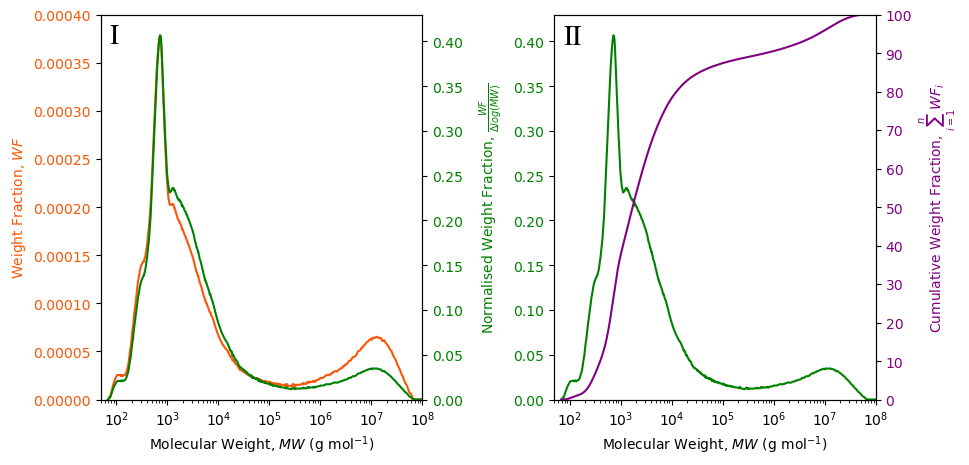

In [16]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10, 5))

ax1.set_ylabel(r'Weight Fraction, $WF$',color="#fb5607")
ax1.set_xlabel(r'Molecular Weight, $MW$ (g mol$^{-1}$)')
ax1.plot(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_wf,label="PPI_ALT",color="#fb5607")
ax1.tick_params(axis='y', labelcolor="#fb5607")
ax1.set_xscale('log')
ax1.set_xlim(50,100000000)
ax1.set_ylim(0.0,0.00040)

ax1_rhs = ax1.twinx()
ax1_rhs.set_ylabel(r'Normalised Weight Fraction, $\frac{WF}{\Delta log(MW)}$',color="green",labelpad=10)
ax1_rhs.plot(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_nwf,color="green")
ax1_rhs.tick_params(axis='y', labelcolor="green")
ax1_rhs.set_xlim(50,100000000)
ax1_rhs.set_ylim(0.0,0.43)

ax2.set_xlabel(r'Molecular Weight, $MW$ (g mol$^{-1}$)')
ax2.plot(Data_HMWR_PPSI_mp,Data_HMWR_PPSI_nwf,color="green")
ax2.set_xscale('log')
ax2.set_ylim(0.0,0.43)
ax2.set_xlim(50,100000000)
ax2.tick_params(axis='y', labelcolor="green")

ax2_rhs = ax2.twinx()
ax2_rhs.plot(list(reversed(Data_HMWR_PPSI_mp)),np.array(Cumulative_wf)*100,color="purple")
ax2_rhs.set_xscale('log')
ax2_rhs.set_xlim(50,100000000)
ax2_rhs.set_ylim(0,100)
ax2_rhs.set_yticks(np.linspace(0,100,11))
ax2_rhs.tick_params(axis='y', labelcolor="purple")
ax2_rhs.set_ylabel(r'Cumulative Weight Fraction, $\sum_{i=1}^{n}WF_{i}$',color="purple")
# fig.tight_layout()
plt.subplots_adjust(wspace=0.41)

ax1.text(x=75,y=0.00037,s="I",fontsize=20,font='times')
ax2.text(x=75,y=0.397,s="II",fontsize=20,font='times')

plt.savefig(fname='GPCNormExplain.png',bbox_inches="tight",dpi=1000,format='png')